# Notebook 3: Traditional ML Models
### Sarcasm Detection in News Headlines — NLP Project
---
**Models:** Naive Bayes · Logistic Regression · SVM

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

sns.set_theme(style='whitegrid')
print('Imports done!')

Imports done!


In [2]:
from joblib import load

# Load data saved with joblib (compatible with current NumPy)
splits = load('../data/splits.joblib')

X_train = splits['X_tfidf_train']
X_val   = splits['X_tfidf_val']
X_test  = splits['X_tfidf_test']
y_train = splits['y_train']
y_val   = splits['y_val']
y_test  = splits['y_test']

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (20031, 19923), Test: (4293, 19923)


## Utility — Evaluate & Plot

In [3]:
results = {}

def evaluate(name, y_true, y_pred, save=True):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    print(f'\n{"="*52}')
    print(f'  {name}')
    print(f'{"="*52}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    print(f'\n{classification_report(y_true, y_pred, target_names=["Not Sarcastic","Sarcastic"])}')
    if save:
        results[name] = dict(Accuracy=acc, Precision=prec, Recall=rec, F1=f1)
    return acc, prec, rec, f1

def plot_cm(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Not Sarcastic','Sarcastic'],
                yticklabels=['Not Sarcastic','Sarcastic'])
    plt.title(f'Confusion Matrix — {name}', fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'../outputs/cm_{name.replace(" ","_").lower()}.png', dpi=150)
    plt.show()

print('Utility functions ready!')

Utility functions ready!


---
## Model 1 — Naive Bayes
Probabilistic baseline using word frequency probabilities. Fast and simple.

--- Validation ---

  Naive Bayes (Val)
  Accuracy : 0.7913
  Precision: 0.7914
  Recall   : 0.7913
  F1-Score : 0.7910

               precision    recall  f1-score   support

Not Sarcastic       0.79      0.82      0.80      2247
    Sarcastic       0.79      0.76      0.78      2046

     accuracy                           0.79      4293
    macro avg       0.79      0.79      0.79      4293
 weighted avg       0.79      0.79      0.79      4293

--- Test ---

  Naive Bayes
  Accuracy : 0.7878
  Precision: 0.7877
  Recall   : 0.7878
  F1-Score : 0.7878

               precision    recall  f1-score   support

Not Sarcastic       0.80      0.80      0.80      2248
    Sarcastic       0.78      0.77      0.78      2045

     accuracy                           0.79      4293
    macro avg       0.79      0.79      0.79      4293
 weighted avg       0.79      0.79      0.79      4293



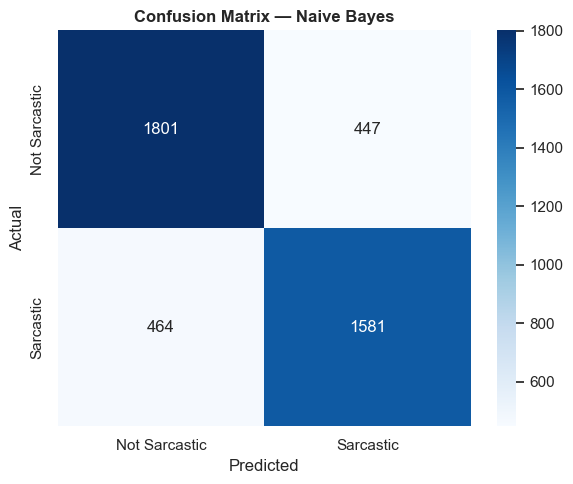

In [4]:
nb = MultinomialNB(alpha=0.1)
nb.fit(X_train, y_train)

print('--- Validation ---')
evaluate('Naive Bayes (Val)', y_val, nb.predict(X_val), save=False)

print('--- Test ---')
evaluate('Naive Bayes', y_test, nb.predict(X_test))
plot_cm('Naive Bayes', y_test, nb.predict(X_test))

---
## Model 2 — Logistic Regression
Linear classifier — learns probability of sarcasm from TF-IDF features.

--- Validation ---

  Logistic Regression (Val)
  Accuracy : 0.7883
  Precision: 0.7900
  Recall   : 0.7883
  F1-Score : 0.7873

               precision    recall  f1-score   support

Not Sarcastic       0.77      0.84      0.81      2247
    Sarcastic       0.81      0.73      0.77      2046

     accuracy                           0.79      4293
    macro avg       0.79      0.79      0.79      4293
 weighted avg       0.79      0.79      0.79      4293

--- Test ---

  Logistic Regression
  Accuracy : 0.7862
  Precision: 0.7871
  Recall   : 0.7862
  F1-Score : 0.7854

               precision    recall  f1-score   support

Not Sarcastic       0.78      0.83      0.80      2248
    Sarcastic       0.80      0.73      0.77      2045

     accuracy                           0.79      4293
    macro avg       0.79      0.78      0.78      4293
 weighted avg       0.79      0.79      0.79      4293



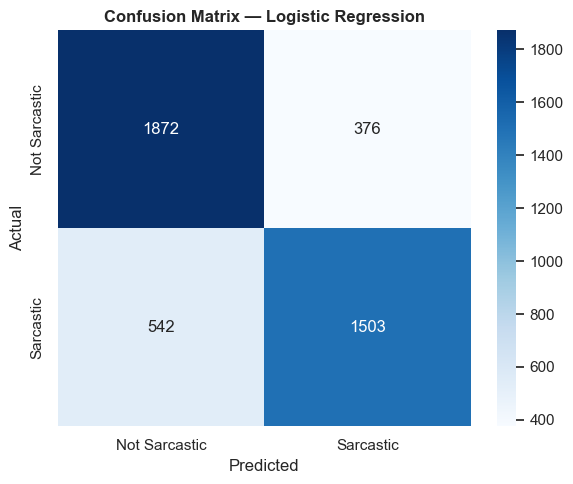

In [5]:
lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42, solver='lbfgs')
lr.fit(X_train, y_train)

print('--- Validation ---')
evaluate('Logistic Regression (Val)', y_val, lr.predict(X_val), save=False)

print('--- Test ---')
evaluate('Logistic Regression', y_test, lr.predict(X_test))
plot_cm('Logistic Regression', y_test, lr.predict(X_test))

---
## Model 3 — Support Vector Machine (LinearSVC)
Finds the maximum-margin hyperplane separating sarcastic from non-sarcastic text. Typically best among traditional ML for text.

--- Validation ---

  SVM (Val)
  Accuracy : 0.8034
  Precision: 0.8038
  Recall   : 0.8034
  F1-Score : 0.8030

               precision    recall  f1-score   support

Not Sarcastic       0.80      0.84      0.82      2247
    Sarcastic       0.81      0.77      0.79      2046

     accuracy                           0.80      4293
    macro avg       0.80      0.80      0.80      4293
 weighted avg       0.80      0.80      0.80      4293

--- Test ---

  SVM
  Accuracy : 0.7957
  Precision: 0.7959
  Recall   : 0.7957
  F1-Score : 0.7954

               precision    recall  f1-score   support

Not Sarcastic       0.79      0.83      0.81      2248
    Sarcastic       0.80      0.76      0.78      2045

     accuracy                           0.80      4293
    macro avg       0.80      0.79      0.79      4293
 weighted avg       0.80      0.80      0.80      4293



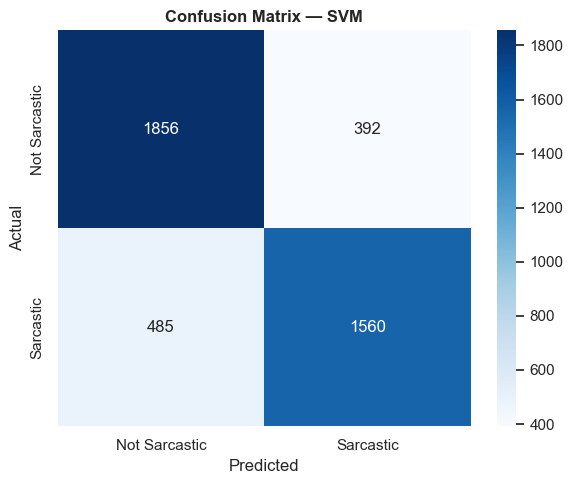

In [6]:
svm = LinearSVC(C=0.5, max_iter=3000, random_state=42)
svm.fit(X_train, y_train)

print('--- Validation ---')
evaluate('SVM (Val)', y_val, svm.predict(X_val), save=False)

print('--- Test ---')
evaluate('SVM', y_test, svm.predict(X_test))
plot_cm('SVM', y_test, svm.predict(X_test))

## Comparison Chart

              Model  Accuracy  Precision  Recall     F1
        Naive Bayes    0.7878     0.7877  0.7878 0.7878
Logistic Regression    0.7862     0.7871  0.7862 0.7854
                SVM    0.7957     0.7959  0.7957 0.7954


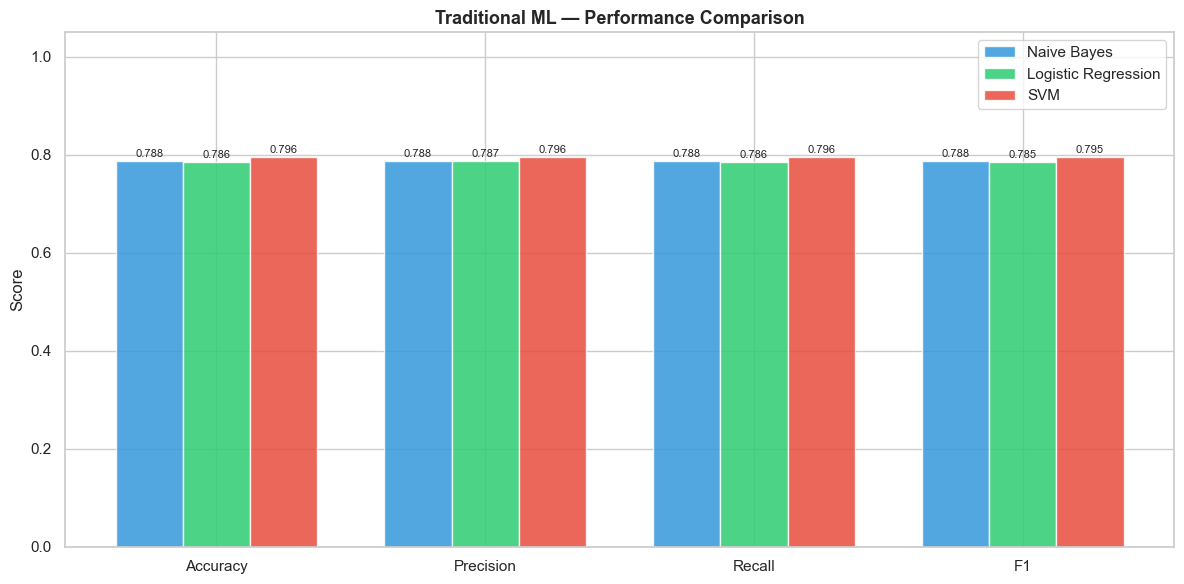

In [7]:
trad_df = pd.DataFrame(results).T.reset_index()
trad_df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1']
print(trad_df.round(4).to_string(index=False))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metrics))
w = 0.25
colors = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (_, row) in enumerate(trad_df.iterrows()):
    bars = ax.bar(x + i*w, [row[m] for m in metrics], w,
                  label=row['Model'], color=colors[i], alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + w); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Traditional ML — Performance Comparison', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/03_traditional_comparison.png', dpi=150)
plt.show()

In [8]:
with open('../data/nb.pkl',      'wb') as f: pickle.dump(nb,  f)
with open('../data/lr.pkl',      'wb') as f: pickle.dump(lr,  f)
with open('../data/svm.pkl',     'wb') as f: pickle.dump(svm, f)
with open('../data/results.pkl', 'wb') as f: pickle.dump(results, f)
print('Saved!')

Saved!
